# Brain Tumor MRI Classification with ResNet50

Classifies brain MRI slices into **glioma**, **meningioma** or **pituitary** tumor using transfer learning (ImageNet-pretrained ResNet50, PyTorch).

### Results

| Evaluation | Test images | Accuracy | Macro F1 |
|---|---|---|---|
| Random image split (70/15/15) | 461 | **98.5%** | 0.982 |
| Patient-level split (no patient in both train and test) | 643 | **93.0%** | 0.922 |

The random split is optimistic because the same patient's MRI slices can appear in both training and test data. The patient-level split (Section 7) is the realistic estimate for new patients.

### Contents
1. Setup
2. Data
3. Preprocessing
4. Model
5. Training
6. Evaluation (random split)
7. Evaluation (patient-level split)
8. Conclusions

> Run on Google Colab with a **T4 GPU** (Runtime → Change runtime type). The trained models are saved to Google Drive.

## 1. Setup

In [1]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## 2. Data

**Dataset:** [Figshare brain tumor dataset](https://doi.org/10.6084/m9.figshare.1512427) (Jun Cheng): 3,064 T1-weighted contrast-enhanced MRI slices from **233 patients**.

Each `.mat` file contains the MRI `image` (512×512), its `label` (1 = meningioma, 2 = glioma, 3 = pituitary), the patient ID and a tumor mask (not used here).

The cell below:
- downloads the dataset from Figshare (first run) or restores a backup from Google Drive (later runs);
- reads each `.mat` file with `h5py` (MATLAB v7.3 files are HDF5), transposing because MATLAB stores data column-first;
- min-max scales the intensities to 0–255 and saves a `.jpg` into a folder named after its class, so the folder name becomes the label.

In [2]:
import os, glob, requests, h5py, numpy as np
from PIL import Image
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content')

backup = "/content/drive/MyDrive/brain_data.zip"

if os.path.exists("data/glioma") and len(os.listdir("data/glioma")) > 0:
    print("Data already here.")
elif os.path.exists(backup):
    print("Restoring from Google Drive...")
    os.system(f'unzip -q -o "{backup}" -d /content')
else:
    print("First time: downloading from Figshare...")
    for f in requests.get("https://api.figshare.com/v2/articles/1512427").json()["files"]:
        print("  downloading", f["name"])
        os.system(f'wget -q -O "{f["name"]}" "{f["download_url"]}"')
    for z in glob.glob("brainTumorDataPublic_*.zip"):
        os.system(f'unzip -q -o "{z}" -d mat')
    mats = glob.glob("mat/**/*.mat", recursive=True)
    print("  .mat files found:", len(mats))

    names = {1: "meningioma", 2: "glioma", 3: "pituitary"}
    for n in names.values():
        os.makedirs(f"data/{n}", exist_ok=True)
    for i, path in enumerate(mats):
        with h5py.File(path, "r") as f:
            img = np.array(f["cjdata/image"]).T          # the MRI picture
            label = int(f["cjdata/label"][0][0])         # its tumor type (1/2/3)
        img = (img - img.min()) / (img.max() - img.min()) * 255
        name = os.path.basename(path).replace(".mat", ".jpg")
        Image.fromarray(img.astype(np.uint8)).save(f"data/{names[label]}/{name}")
        if i % 500 == 0:
            print("  converted", i)
    os.system(f'zip -qr "{backup}" data')
    print("Backup saved to Google Drive.")

for n in ["glioma", "meningioma", "pituitary"]:
    print(n, len(os.listdir(f"data/{n}")))

First time: downloading from Figshare...
  downloading brainTumorDataPublic_1-766.zip
  downloading brainTumorDataPublic_1533-2298.zip
  downloading brainTumorDataPublic_767-1532.zip
  downloading brainTumorDataPublic_2299-3064.zip
  downloading cvind.mat
  downloading README 2024.txt
  .mat files found: 3064
  converted 0
  converted 500
  converted 1000
  converted 1500
  converted 2000
  converted 2500
  converted 3000
Backup saved to Google Drive.
glioma 1426
meningioma 708
pituitary 930


The classes are **imbalanced**: glioma has about twice as many images as meningioma.

One example from each class:

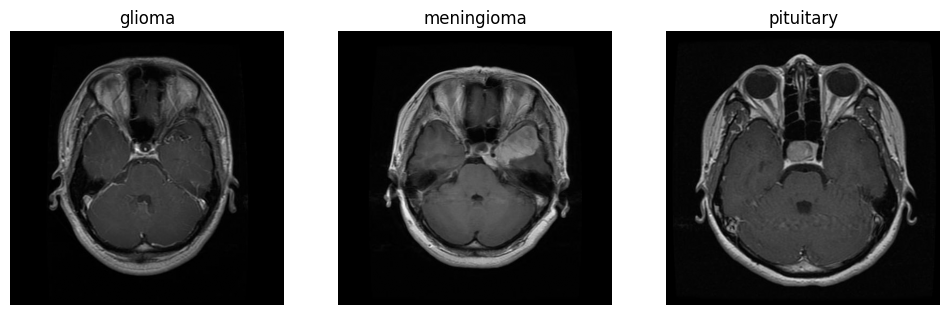

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, name in zip(axes, ["glioma", "meningioma", "pituitary"]):
    first = sorted(os.listdir(f"data/{name}"))[0]
    ax.imshow(Image.open(f"data/{name}/{first}"), cmap="gray")
    ax.set_title(name); ax.axis("off")
plt.show()

## 3. Preprocessing

- **Resize to 224×224**, the input size ResNet50 was designed for.
- **Augmentation (training only):** random horizontal/vertical flips, ±15° rotation, brightness/contrast jitter. This reduces overfitting on a small dataset.
- **Normalisation** with ImageNet mean and standard deviation, matching the data the backbone was pretrained on.
- Validation and test images are only resized and normalised, so they are measured unchanged.

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

mean = [0.485, 0.456, 0.406]   # ImageNet average colour
std  = [0.229, 0.224, 0.225]   # ImageNet colour spread

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

**Split:** 70% train / 15% validation / 15% test, shuffled with a fixed seed for reproducibility. `ImageFolder` assigns labels alphabetically: glioma = 0, meningioma = 1, pituitary = 2.

In [5]:
train_full = datasets.ImageFolder("data", transform=train_tf)
eval_full  = datasets.ImageFolder("data", transform=eval_tf)
print(train_full.classes)

g = torch.Generator().manual_seed(42)
idx = torch.randperm(len(train_full), generator=g).tolist()
n = len(idx)
n_train, n_val = int(0.70 * n), int(0.15 * n)

train_ds = Subset(train_full, idx[:n_train])
val_ds   = Subset(eval_full,  idx[n_train:n_train + n_val])
test_ds  = Subset(eval_full,  idx[n_train + n_val:])
print(len(train_ds), len(val_ds), len(test_ds))

['glioma', 'meningioma', 'pituitary']
2144 459 461


**DataLoaders:** batches of 32, shuffled every epoch for training.

In [6]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, num_workers=2)

One augmented training batch (images un-normalised for display):

torch.Size([32, 3, 224, 224])


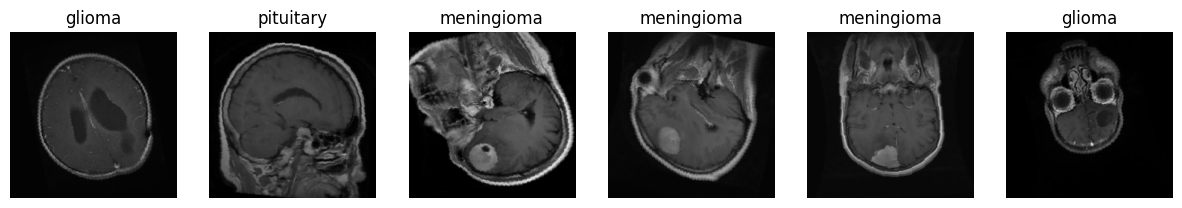

In [7]:
images, labels = next(iter(train_loader))
print(images.shape)   # expect torch.Size([32, 3, 224, 224])

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0) * torch.tensor(std) + torch.tensor(mean)  # undo normalise for viewing
    ax.imshow(img.clamp(0, 1)); ax.set_title(train_full.classes[labels[i]]); ax.axis("off")
plt.show()

## 4. Model

**Transfer learning:** ResNet50 pretrained on ImageNet (1.2M images) already detects edges, textures and shapes. We keep that backbone and replace only the final 1,000-class layer.

In [8]:
import torch.nn as nn
from torchvision import models

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


**New classification head:** `Linear(2048→512) → ReLU → Dropout(0.5) → Linear(512→3)`.

No softmax layer is added, because `CrossEntropyLoss` applies it internally.

In [9]:
model.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 3),
)
model = model.to(device)   # move the model onto the GPU

**Freeze the backbone for warm-up.** The new head starts with random weights, so its early gradients are large. Training only the head first protects the pretrained features. The whole network is unfrozen afterwards.

In [10]:
for name, p in model.named_parameters():
    p.requires_grad = name.startswith("fc")   # only our new head can learn

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

Trainable: 1,050,627 / 24,558,659


**Sanity check:** the untrained model outputs roughly equal probabilities (≈0.33 per class) with the expected shape `[32, 3]`.

In [11]:
model.eval()
with torch.no_grad():
    out = model(images.to(device))
print(out.shape)
print(torch.softmax(out, dim=1)[:3])

torch.Size([32, 3])
tensor([[0.3222, 0.3302, 0.3476],
        [0.3242, 0.3396, 0.3363],
        [0.3081, 0.3563, 0.3357]], device='cuda:0')


## 5. Training

`run_epoch()` performs one pass over a DataLoader. With an optimizer it trains (forward pass → loss → backpropagation → weight update). Without one it only evaluates.

In [12]:
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, count = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)                 # 1. forward pass
            loss = criterion(outputs, labels)       # 2. how wrong?
            if training:
                optimizer.zero_grad()               # clear the old directions
                loss.backward()                     # 3. find the directions
                optimizer.step()                    # 4. nudge the weights
            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            count += labels.size(0)

    return total_loss / count, correct / count

**Phase 1 – warm-up (3 epochs):** only the new head is trained (Adam, lr = 1e-3).

In [13]:
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
history = []

for epoch in range(3):
    tr_loss, tr_acc = run_epoch(train_loader, optimizer)
    va_loss, va_acc = run_epoch(val_loader)
    history.append((tr_loss, va_loss, tr_acc, va_acc))
    print(f"Warm-up {epoch+1}/3 | train loss {tr_loss:.3f} acc {tr_acc:.1%} | val loss {va_loss:.3f} acc {va_acc:.1%}")

Warm-up 1/3 | train loss 0.614 acc 72.5% | val loss 0.442 acc 81.9%
Warm-up 2/3 | train loss 0.421 acc 82.3% | val loss 0.355 acc 86.7%
Warm-up 3/3 | train loss 0.391 acc 83.6% | val loss 0.426 acc 83.2%


**Phase 2 – fine-tuning (15 epochs):** the whole network is unfrozen.
- Backbone lr = 1e-4, head lr = 1e-3, so the pretrained weights are only adjusted gently.
- StepLR multiplies all learning rates by 0.1 every 7 epochs.
- The model with the best **validation** accuracy is saved.

In [14]:
for p in model.parameters():
    p.requires_grad = True                     # unfreeze everything

backbone = [p for n, p in model.named_parameters() if not n.startswith("fc")]
optimizer = torch.optim.Adam([
    {"params": backbone,               "lr": 1e-4},   # small steps: protect what it knows
    {"params": model.fc.parameters(),  "lr": 1e-3},   # bigger steps: the head is still new
])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

save_path = "/content/drive/MyDrive/brain_tumor_model.pt"
best_acc = 0

for epoch in range(15):
    tr_loss, tr_acc = run_epoch(train_loader, optimizer)
    va_loss, va_acc = run_epoch(val_loader)
    scheduler.step()
    history.append((tr_loss, va_loss, tr_acc, va_acc))
    print(f"Epoch {epoch+1}/15 | train loss {tr_loss:.3f} acc {tr_acc:.1%} | val loss {va_loss:.3f} acc {va_acc:.1%}")

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), save_path)
        print("   ✓ best so far, saved")

Epoch 1/15 | train loss 0.281 acc 88.9% | val loss 0.194 acc 93.2%
   ✓ best so far, saved
Epoch 2/15 | train loss 0.159 acc 93.4% | val loss 0.122 acc 94.3%
   ✓ best so far, saved
Epoch 3/15 | train loss 0.128 acc 94.8% | val loss 0.268 acc 89.8%
Epoch 4/15 | train loss 0.105 acc 95.9% | val loss 0.112 acc 96.5%
   ✓ best so far, saved
Epoch 5/15 | train loss 0.078 acc 97.1% | val loss 0.098 acc 97.4%
   ✓ best so far, saved
Epoch 6/15 | train loss 0.052 acc 98.1% | val loss 0.125 acc 95.2%
Epoch 7/15 | train loss 0.054 acc 97.9% | val loss 0.080 acc 96.9%
Epoch 8/15 | train loss 0.039 acc 98.6% | val loss 0.069 acc 97.4%
Epoch 9/15 | train loss 0.025 acc 99.4% | val loss 0.058 acc 98.3%
   ✓ best so far, saved
Epoch 10/15 | train loss 0.023 acc 99.2% | val loss 0.057 acc 98.0%
Epoch 11/15 | train loss 0.021 acc 99.4% | val loss 0.053 acc 97.8%
Epoch 12/15 | train loss 0.018 acc 99.5% | val loss 0.057 acc 97.4%
Epoch 13/15 | train loss 0.014 acc 99.6% | val loss 0.054 acc 97.4%
Epoch

**Learning curves** (dashed line = start of fine-tuning):

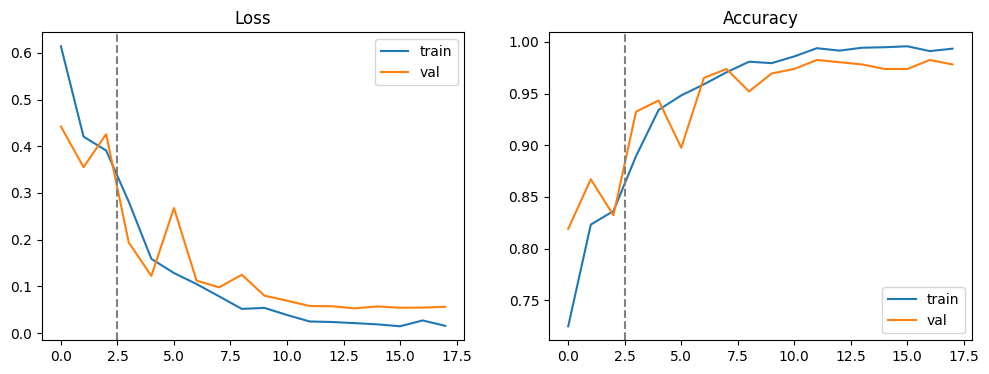

In [15]:
h = list(zip(*history))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(h[0], label="train"); a1.plot(h[1], label="val"); a1.set_title("Loss"); a1.legend()
a2.plot(h[2], label="train"); a2.plot(h[3], label="val"); a2.set_title("Accuracy"); a2.legend()
for a in (a1, a2): a.axvline(2.5, ls="--", c="gray")   # where fine-tuning starts
plt.show()

## 6. Evaluation (random split)

The best checkpoint is evaluated once on the held-out test set.

In [16]:
model.load_state_dict(torch.load(save_path))
te_loss, te_acc = run_epoch(test_loader)
print(f"TEST accuracy: {te_acc:.1%}")

TEST accuracy: 98.5%


              precision    recall  f1-score   support

      glioma      0.991     0.987     0.989       226
  meningioma      0.971     0.961     0.966       103
   pituitary      0.985     1.000     0.992       132

    accuracy                          0.985       461
   macro avg      0.982     0.983     0.982       461
weighted avg      0.985     0.985     0.985       461



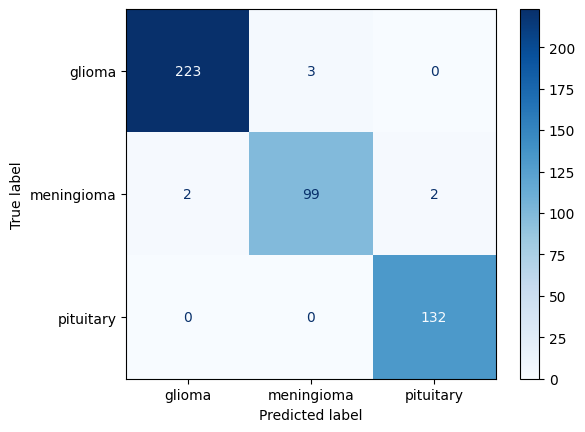

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in loader:
            preds += model(x.to(device)).argmax(1).cpu().tolist()
            trues += y.tolist()
    print(classification_report(trues, preds, target_names=train_full.classes, digits=3))
    ConfusionMatrixDisplay(confusion_matrix(trues, preds),
                           display_labels=train_full.classes).plot(cmap="Blues")
    plt.show()

evaluate(test_loader)

## 7. Evaluation (patient-level split)

The dataset has ~13 slices per patient, and neighbouring slices look almost identical. A random image split lets slices of the **same patient** appear in both training and test data, so the model can partly recognise the patient rather than the tumor (**data leakage**).

To measure performance on unseen patients, we use the dataset's official `cvind.mat` file, which assigns every image to one of 5 **patient-disjoint folds**:
- folds 1–3 → train, fold 4 → validation, fold 5 → test

In [18]:
import scipy.io, requests

if not os.path.exists("cvind.mat"):
    f = [x for x in requests.get("https://api.figshare.com/v2/articles/1512427").json()["files"]
         if x["name"] == "cvind.mat"][0]
    os.system(f'wget -q -O cvind.mat "{f["download_url"]}"')

try:
    folds = scipy.io.loadmat("cvind.mat")["cvind"].flatten()
except NotImplementedError:                      # in case it's the newer MATLAB format
    folds = np.array(h5py.File("cvind.mat", "r")["cvind"]).flatten()

print(len(folds), np.unique(folds, return_counts=True))

3064 (array([1., 2., 3., 4., 5.]), array([542, 679, 572, 628, 643]))


In [19]:
def fold_of(path):
    num = int(os.path.basename(path).replace(".jpg", ""))   # "123.jpg" came from "123.mat"
    return folds[num - 1]

img_folds = [fold_of(p) for p, _ in train_full.samples]
tr_idx = [i for i, f in enumerate(img_folds) if f in (1, 2, 3)]
va_idx = [i for i, f in enumerate(img_folds) if f == 4]
te_idx = [i for i, f in enumerate(img_folds) if f == 5]

p_train_loader = DataLoader(Subset(train_full, tr_idx), batch_size=32, shuffle=True, num_workers=2)
p_val_loader   = DataLoader(Subset(eval_full,  va_idx), batch_size=32, num_workers=2)
p_test_loader  = DataLoader(Subset(eval_full,  te_idx), batch_size=32, num_workers=2)
print(len(tr_idx), len(va_idx), len(te_idx))

1793 628 643


The same model and training procedure is retrained from scratch on the patient-level split:

warm-up 1/3 done
warm-up 2/3 done
warm-up 3/3 done
Epoch 1/15 | train acc 87.7% | val acc 88.9%
Epoch 2/15 | train acc 93.5% | val acc 93.3%
Epoch 3/15 | train acc 95.8% | val acc 94.1%
Epoch 4/15 | train acc 95.8% | val acc 91.6%
Epoch 5/15 | train acc 96.7% | val acc 90.8%
Epoch 6/15 | train acc 97.7% | val acc 92.0%
Epoch 7/15 | train acc 98.3% | val acc 95.2%
Epoch 8/15 | train acc 98.5% | val acc 94.9%
Epoch 9/15 | train acc 99.0% | val acc 95.7%
Epoch 10/15 | train acc 98.8% | val acc 95.7%
Epoch 11/15 | train acc 99.1% | val acc 95.9%
Epoch 12/15 | train acc 99.1% | val acc 95.2%
Epoch 13/15 | train acc 99.0% | val acc 96.0%
Epoch 14/15 | train acc 99.0% | val acc 95.9%
Epoch 15/15 | train acc 99.3% | val acc 95.9%
              precision    recall  f1-score   support

      glioma      0.985     0.941     0.963       287
  meningioma      0.892     0.843     0.867       166
   pituitary      0.887     0.989     0.935       190

    accuracy                          0.930       

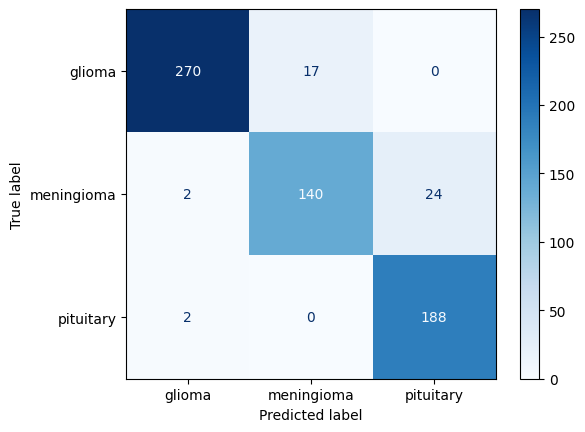

In [20]:
def train_model(train_loader, val_loader, save_path, warmup=3, finetune=15):
    global model   # run_epoch() uses the variable "model", so we replace it here
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, 3))
    model = model.to(device)

    # Phase 1: warm-up, head only
    for n, p in model.named_parameters():
        p.requires_grad = n.startswith("fc")
    opt = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
    for e in range(warmup):
        run_epoch(train_loader, opt)
        print(f"warm-up {e+1}/{warmup} done")

    # Phase 2: fine-tune everything
    for p in model.parameters():
        p.requires_grad = True
    backbone = [p for n, p in model.named_parameters() if not n.startswith("fc")]
    opt = torch.optim.Adam([{"params": backbone, "lr": 1e-4},
                            {"params": model.fc.parameters(), "lr": 1e-3}])
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.1)

    best = 0
    for e in range(finetune):
        tr_loss, tr_acc = run_epoch(train_loader, opt)
        va_loss, va_acc = run_epoch(val_loader)
        sched.step()
        print(f"Epoch {e+1}/{finetune} | train acc {tr_acc:.1%} | val acc {va_acc:.1%}")
        if va_acc > best:
            best = va_acc
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path))
    return model

model = train_model(p_train_loader, p_val_loader, "/content/drive/MyDrive/brain_tumor_model_patient.pt")
evaluate(p_test_loader)

## 8. Conclusions

| Class | F1 (random split) | F1 (patient split) |
|---|---|---|
| Glioma | 0.989 | 0.963 |
| Meningioma | 0.966 | 0.867 |
| Pituitary | 0.992 | 0.935 |
| **Accuracy** | **98.5%** | **93.0%** |

- Transfer learning with ResNet50 reaches **98.5%** on a random split, matching the originally reported ~99%.
- On **patients the model has never seen**, accuracy drops to **93.0%**. The ~5.5-point gap shows how much patient-level leakage inflates the random-split result.
- **Meningioma** is the hardest class (F1 0.867), and it is also the smallest class (708 images).

**Limitations:** single dataset from one source, only 3 tumor classes (no "no tumor" class), and not validated for clinical use.

**Possible improvements:** class-weighted loss for meningioma, Grad-CAM to check that the model focuses on the tumor region, and 5-fold patient-level cross-validation for a more stable estimate.